# Trabalho de Teoria dos Grafos - Parte 02
## Análise de Acessibilidade a Serviços Públicos em Lauro Müller (SC) e Arvoredo (SC)
**Aluno:** Julio Cesar Vanz & Eduardo Degan<br>
**Disciplina:** Teoria dos Grafos

In [34]:
# Importação de bibliotecas necessárias
import osmnx as ox
import networkx as nx
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from shapely.geometry import Point
import warnings

warnings.filterwarnings('ignore')
ox.settings.use_cache = True

## 1 - Obtenção e Modelagem do Grafo das Cidades

Nesta etapa, faremos o download da malha viária das cidades de **Lauro Müller (SC)** e **Arvoredo (SC)** do OpenStreetMap (OSM).
Para garantir que as análises de caminhos mais curtos sejam robustas e sem erros de desconexão, extrairemos o **maior componente fracamente conectado** de cada grafo e converteremos o grafo para não-direcionado.

In [35]:
# Coordenadas centrais de cada cidade
centro_lauro = (-28.391230, -49.393544)
centro_arvoredo = (-27.075508, -52.457085)

# Baixa o grafo viário de Lauro Müller limitado a área urbana (5km)
G_lauro = ox.graph_from_point(centro_lauro, dist=5000, network_type='drive')
G_lauro = ox.truncate.largest_component(G_lauro, strongly=False)
G_lauro = ox.convert.to_undirected(G_lauro)

# Baixa o grafo viário de Arvoredo limitado à área urbana (1.5km)
G_arvoredo = ox.graph_from_point(centro_arvoredo, dist=1500, network_type='drive')
G_arvoredo = ox.truncate.largest_component(G_arvoredo, strongly=False)
G_arvoredo = ox.convert.to_undirected(G_arvoredo)

print(f'Lauro Müller - Grafo Urbano: {len(G_lauro.nodes)} nós e {len(G_lauro.edges)} arestas.')
print(f'Arvoredo - Grafo Urbano: {len(G_arvoredo.nodes)} nós e {len(G_arvoredo.edges)} arestas.')

Lauro Müller - Grafo Urbano: 713 nós e 917 arestas.
Arvoredo - Grafo Urbano: 82 nós e 104 arestas.


### Organização do Grafo por Bairros/Setores

Organização dos grafos separando as vias e conexões por bairros para facilitar a análise:
1. **Lauro Müller (SC)**: O grafo da área urbana será repartido associando cada nó do grafo ao bairro/distrito mais próximo, dentre as principais residencias e comercios identificados (Centro, Barro Branco, Guatá, Sumaré, Arizona, Cairu).
2. **Arvoredo (SC)**: Por ser um núcleo urbano compacto e sem bairros administrativos definidos em bases oficiais, a cidade em si será dividida em **4 Setores** (Setor Noroeste, Setor Nordeste, Setor Sudoeste e Setor Sudeste). Cada nó será atribuído ao setor cujo centro está mais próximo.

In [36]:
# Função para calcular distância euclidiana para associação rápida
def encontrar_bairro_mais_proximo(lat, lon, bairros_dict):
    melhor_bairro = None
    menor_dist = float('inf')
    for bairro, coords in bairros_dict.items():
        dist = (lat - coords[0])**2 + (lon - coords[1])**2
        if dist < menor_dist:
            menor_dist = dist
            melhor_bairro = bairro
    return melhor_bairro

# Centro dos Bairros de Lauro Müller
bairros_lauro = {
    'Centro': (-28.391230, -49.393544),
    'Barro Branco': (-28.414881, -49.412235),
    'Guatá': (-28.381083, -49.438467),
    'Sumaré': (-28.3908, -49.3905),
    'Arizona': (-28.390549, -49.381129),
    'Cairu': (-28.3908, -49.3993)
}

# Centro dos Setores da cidade de Arvoredo
bairros_arvoredo = {
    'Setor Noroeste': (-27.0720, -52.4580),
    'Setor Nordeste': (-27.0720, -52.4500),
    'Setor Sudoeste': (-27.0780, -52.4580),
    'Setor Sudeste': (-27.0780, -52.4500)
}

# Atribui o bairro correspondente a cada nó do grafo de Lauro Müller
for node, data in G_lauro.nodes(data=True):
    lat, lon = data['y'], data['x']
    data['bairro'] = encontrar_bairro_mais_proximo(lat, lon, bairros_lauro)

# Atribui o setor correspondente a cada nó do grafo de Arvoredo
for node, data in G_arvoredo.nodes(data=True):
    lat, lon = data['y'], data['x']
    data['bairro'] = encontrar_bairro_mais_proximo(lat, lon, bairros_arvoredo)

# Contagem de nós por bairro/região
df_cont_lm = pd.Series([data['bairro'] for _, data in G_lauro.nodes(data=True)]).value_counts()
df_cont_ar = pd.Series([data['bairro'] for _, data in G_arvoredo.nodes(data=True)]).value_counts()

print('=== NÓS POR BAIRRO EM LAURO MÜLLER ===')
print(df_cont_lm)
print('\n=== NÓS POR SETOR EM ARVOREDO ===')
print(df_cont_ar)

=== NÓS POR BAIRRO EM LAURO MÜLLER ===
Barro Branco    253
Guatá           118
Cairu           115
Arizona          91
Sumaré           78
Centro           58
Name: count, dtype: int64

=== NÓS POR SETOR EM ARVOREDO ===
Setor Noroeste    32
Setor Sudoeste    24
Setor Sudeste     20
Setor Nordeste     6
Name: count, dtype: int64


### Visualização dos Bairros/Regiões repartidos no Grafo

Para analisar visualmente a divisão territorial, geraremos mapas colorindo os nós da malha viária com base no bairro ou região a que foram atribuídos. Cada cor no grafo representa uma divisão territorial associada ao seu respectivo centro.

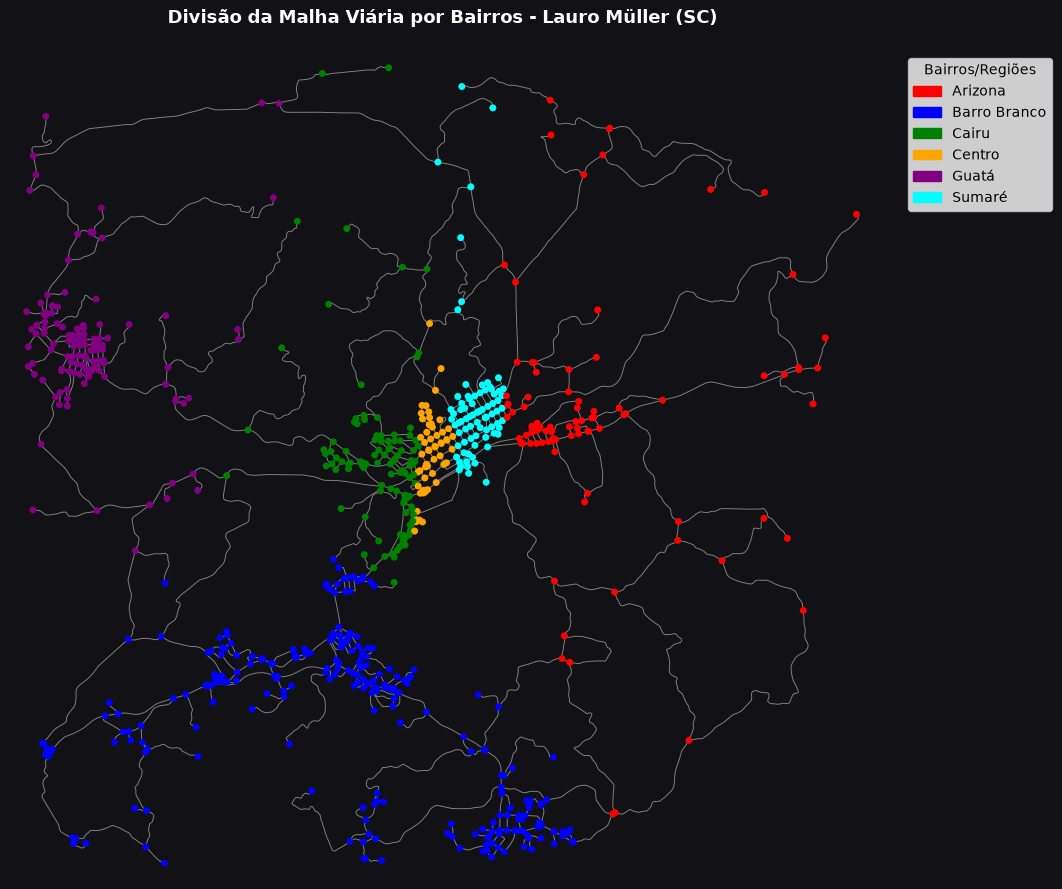

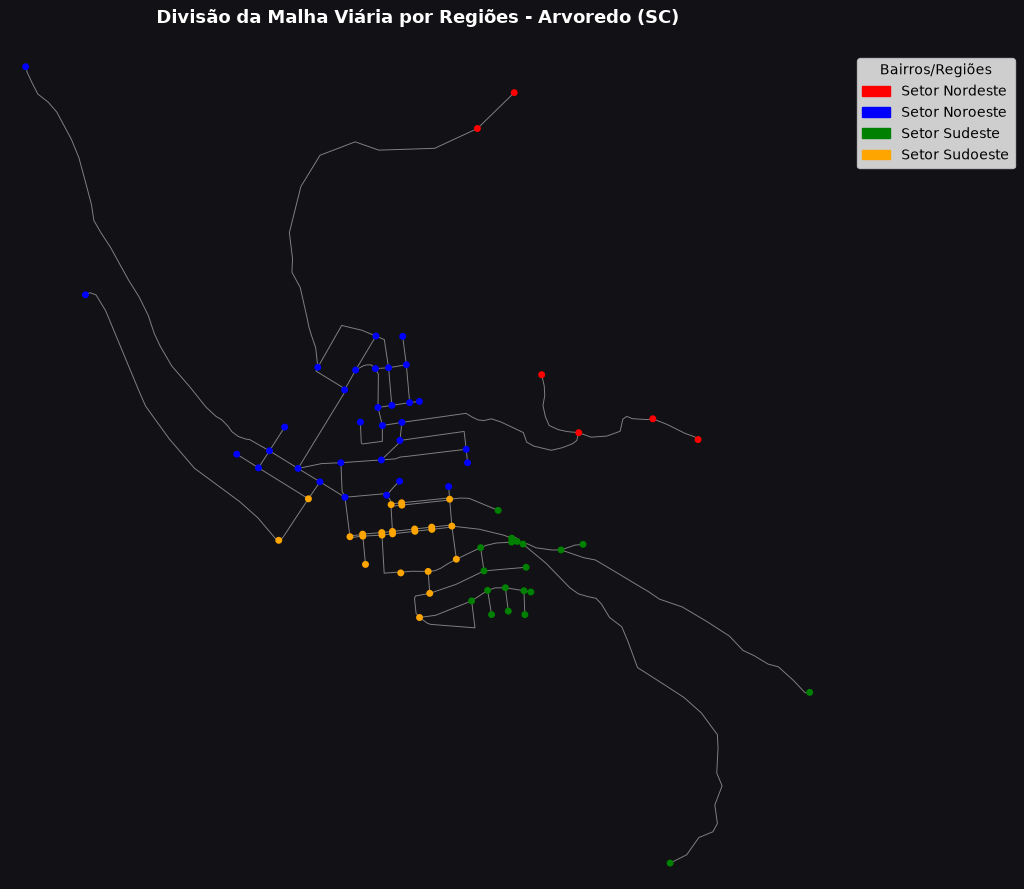

In [37]:
# Desenha o grafo usando uma cor para cada bairro
import matplotlib.patches as mpatches

def desenhar_grafo_por_bairros(G, bairros, titulo, nome_arquivo):
    nomes_bairros = sorted(bairros.keys())
    cores = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']
    cor_bairro = {
        bairro: cores[i % len(cores)]
        for i, bairro in enumerate(nomes_bairros)
    }

    cores_nos = [
        cor_bairro.get(dados.get('bairro'), 'gray')
        for _, dados in G.nodes(data=True)
    ]

    fig, ax = plt.subplots(figsize=(11, 9), facecolor='#111116')
    ax.set_facecolor('#111116')

    ox.plot_graph(
        G, ax=ax, node_color=cores_nos, node_size=25,
        edge_color='gray', edge_linewidth=0.7, show=False,
        close=False
    )

    ax.set_title(titulo, fontsize=13, fontweight='bold', color='#ffffff', pad=20)

    legenda = [
        mpatches.Patch(color=cor_bairro[bairro], label=bairro)
        for bairro in nomes_bairros
    ]
    leg = ax.legend(
        handles=legenda, title='Bairros/Regiões',
        bbox_to_anchor=(1.03, 1), loc='upper left'
    )

    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=300, facecolor='#111116', bbox_inches='tight')
    plt.show()

desenhar_grafo_por_bairros(G_lauro, bairros_lauro, 'Divisão da Malha Viária por Bairros - Lauro Müller (SC)', 'mapa_bairros_lauro.png')
desenhar_grafo_por_bairros(G_arvoredo, bairros_arvoredo, 'Divisão da Malha Viária por Regiões - Arvoredo (SC)', 'mapa_bairros_arvoredo.png')

## 2 - Complementação do Grafo com Serviços Públicos e Pontos de Referência

Foi definido **3 Pontos de Referência** em cada cidade para servir de origem para a análise de acessibilidade. Além disso, foi referenciado os **Serviços Públicos** essenciais (Escolas, Creches, CRAS, Postos de Saúde e Hospitais) utilizando a localização de pontos reais em ambas as cidades.

Os pontos geográficos serão associados aos nós do grafo viário mais próximos (`ox.nearest_nodes`), adicionando atributos ao grafo para que fosse possível calcular rotas e conexões a partir deles.

In [38]:
# Definição dos Pontos de Referência 
pontos_ref_lauro = {
    'Ref 1: Prefeitura Municipal (Centro)': (-28.392764, -49.395914),
    'Ref 2: Praça da Igreja (Barro Branco)': (-28.414881, -49.412235),
    'Ref 3: Praça da Igreja (Guatá)': (-28.381083, -49.438467)
}

pontos_ref_arvoredo = {
    'Ref 1: Prefeitura Municipal (Centro)': (-27.073500, -52.455200),
    'Ref 2: Praça Central (Centro)': (-27.074800, -52.456500),
    'Ref 3: Pórtico de Entrada (Leste)': (-27.073800, -52.448500)
}

# Definição dos Serviços Públicos
servicos_lauro = [
    # Hospitais
    {'nome': 'Hospital Henrique Lage', 'tipo': 'Hospital', 'lat': -28.393847, 'lon': -49.397042, 'bairro': 'Centro'},
    # Postos de Saúde (UBS)
    {'nome': 'ESF Centro', 'tipo': 'Saúde', 'lat': -28.391230, 'lon': -49.393544, 'bairro': 'Centro'},
    {'nome': 'ESF Barro Branco', 'tipo': 'Saúde', 'lat': -28.414881, 'lon': -49.412235, 'bairro': 'Barro Branco'},
    {'nome': 'ESF Guatá', 'tipo': 'Saúde', 'lat': -28.381083, 'lon': -49.438467, 'bairro': 'Guatá'},
    {'nome': 'ESF Arizona', 'tipo': 'Saúde', 'lat': -28.390549, 'lon': -49.381129, 'bairro': 'Arizona'},
    # Escolas
    {'nome': 'EEB Visconde de Taunay', 'tipo': 'Escola', 'lat': -28.3908, 'lon': -49.3905, 'bairro': 'Sumaré'},
    {'nome': 'EEB Walter Holthausen', 'tipo': 'Escola', 'lat': -28.3942, 'lon': -49.3980, 'bairro': 'Centro'},
    {'nome': 'E.M. Hilário Pescador', 'tipo': 'Escola', 'lat': -28.3888, 'lon': -49.3900, 'bairro': 'Sumaré'},
    {'nome': 'E.M. Profª Emília Mamede Soares', 'tipo': 'Escola', 'lat': -28.4140, 'lon': -49.4120, 'bairro': 'Barro Branco'},
    # Creches
    {'nome': 'CEI Irani Vargas', 'tipo': 'Creche', 'lat': -28.3908, 'lon': -49.3993, 'bairro': 'Cairu'},
    {'nome': 'CEI Criança Feliz', 'tipo': 'Creche', 'lat': -28.4140, 'lon': -49.4120, 'bairro': 'Barro Branco'},
    # Assistência Social
    {'nome': 'CRAS Manoel João Nasário', 'tipo': 'Social/Psi', 'lat': -28.3920, 'lon': -49.3950, 'bairro': 'Centro'}
]

servicos_arvoredo = [
    # Saúde (UBS/Ambulatório como principal ponto de saúde e urgência)
    {'nome': 'Centro Municipal de Saúde de Arvoredo (UBS)', 'tipo': 'Saúde', 'lat': -27.0730, 'lon': -52.4503, 'bairro': 'Centro'},
    # Hospital (Simulação de Unidade Avançada/Ambulatório 24h acoplada à UBS, pois a cidade de Arvoredo não possui hospital de grande porte próprio)
    {'nome': 'Unidade Avançada/Ambulatório de Emergência 24h', 'tipo': 'Hospital', 'lat': -27.0730, 'lon': -52.4503, 'bairro': 'Centro'},
    # Escolas
    {'nome': 'EEB Prof. Bento Gonçalves Cardoso', 'tipo': 'Escola', 'lat': -27.0759, 'lon': -52.4558, 'bairro': 'Centro'},
    {'nome': 'Escola Municipal Arvoredo', 'tipo': 'Escola', 'lat': -27.0738, 'lon': -52.4569, 'bairro': 'Centro'},
    # Creches
    {'nome': 'CEI Municipal Arvoredo', 'tipo': 'Creche', 'lat': -27.0750, 'lon': -52.4570, 'bairro': 'Centro'},
    # Assistência Social
    {'nome': 'CRAS Arvoredo', 'tipo': 'Social/Psi', 'lat': -27.0738, 'lon': -52.4569, 'bairro': 'Centro'}
]

def associar_pontos_ao_grafo(G, pontos_ref, lista_servicos):
    # Associa Pontos de Referência aos nós mais próximos
    pontos_ref_nos = {}
    for nome, (lat, lon) in pontos_ref.items():
        no_id = ox.nearest_nodes(G, X=lon, Y=lat)
        pontos_ref_nos[nome] = no_id
        # Adiciona marca no nó
        G.nodes[no_id]['tipo_ponto'] = 'referencia'
        G.nodes[no_id]['nome_ponto'] = nome
        
    # Associa Serviços Públicos aos nós mais próximos
    servicos_nos = []
    for serv in lista_servicos:
        no_id = ox.nearest_nodes(G, X=serv['lon'], Y=serv['lat'])
        serv_info = serv.copy()
        serv_info['node_id'] = no_id
        # Sobrescreve o bairro real pelo bairro do nó associado no grafo
        serv_info['bairro'] = G.nodes[no_id].get('bairro', serv['bairro'])
        servicos_nos.append(serv_info)
        
        # Armazena informações no próprio nó
        if 'servicos' not in G.nodes[no_id]:
            G.nodes[no_id]['servicos'] = []
        G.nodes[no_id]['servicos'].append(serv_info)
        G.nodes[no_id]['tipo_ponto'] = 'servico'
        
    return pontos_ref_nos, servicos_nos

ref_nos_lauro, serv_nos_lauro = associar_pontos_ao_grafo(G_lauro, pontos_ref_lauro, servicos_lauro)
ref_nos_arvoredo, serv_nos_arvoredo = associar_pontos_ao_grafo(G_arvoredo, pontos_ref_arvoredo, servicos_arvoredo)

print(f'Lauro Müller: {len(ref_nos_lauro)} referências e {len(serv_nos_lauro)} serviços mapeados.')
print(f'Arvoredo: {len(ref_nos_arvoredo)} referências e {len(serv_nos_arvoredo)} serviços mapeados.')

Lauro Müller: 3 referências e 12 serviços mapeados.
Arvoredo: 3 referências e 6 serviços mapeados.


## 3 - Análise e Visualização Espacial
### Caminho Mais Curto até o Serviço Mais Próximo

Calculamos o caminho mais curto de cada um dos **3 Pontos de Referência** para o serviço público mais próximo em cada uma das categorias: **Escola**, **Creche**, **Social/Psi**, **Saúde** e **Hospital**.

Nesta parte, foi utilizado o algoritmo de Dijkstra implementado no `networkx` (`nx.shortest_path_length` e `nx.shortest_path`).

In [39]:
def calcular_caminhos_mais_curtos(G, ref_nos, servicos_nos):
    resultados = []
    rotas = {} 
    
    tipos_servico = ['Escola', 'Creche', 'Social/Psi', 'Saúde', 'Hospital']
    
    for ref_nome, ref_node in ref_nos.items():
        for tipo in tipos_servico:
            # Filtra serviços do tipo atual
            servs_tipo = [s for s in servicos_nos if s['tipo'] == tipo]
            
            if not servs_tipo:
                continue
                
            melhor_dist = float('inf')
            melhor_serv = None
            melhor_rota = None
            
            for s in servs_tipo:
                dest_node = s['node_id']
                try:
                    # Calcula distância mais curta usando comprimento da via
                    dist = nx.shortest_path_length(G, ref_node, dest_node, weight='length')
                    if dist < melhor_dist:
                        melhor_dist = dist
                        melhor_serv = s
                        melhor_rota = nx.shortest_path(G, ref_node, dest_node, weight='length')
                except nx.NetworkXNoPath:
                    continue
            
            if melhor_serv:
                resultados.append({
                    'Ponto de Referência': ref_nome,
                    'Tipo de Serviço': tipo,
                    'Serviço Mais Próximo': melhor_serv['nome'],
                    'Bairro Destino': melhor_serv['bairro'],
                    'Distância (m)': round(melhor_dist, 1),
                    'Tempo Estimado (caminhada - 4.5 km/h)': f'{round((melhor_dist / 1250) * 15, 1)} min' 
                })
                rotas[(ref_nome, tipo)] = melhor_rota
                
    return pd.DataFrame(resultados), rotas

df_rotas_lauro, rotas_lauro = calcular_caminhos_mais_curtos(G_lauro, ref_nos_lauro, serv_nos_lauro)
df_rotas_arvoredo, rotas_arvoredo = calcular_caminhos_mais_curtos(G_arvoredo, ref_nos_arvoredo, serv_nos_arvoredo)

print('=== TABELA DE ROTAS MAIS CURTAS: LAURO MÜLLER ===')
display(df_rotas_lauro)
print('\n=== TABELA DE ROTAS MAIS CURTAS: ARVOREDO ===')
display(df_rotas_arvoredo)

=== TABELA DE ROTAS MAIS CURTAS: LAURO MÜLLER ===


,Ponto de Referência,Tipo de Serviço,Serviço Mais Próximo,Bairro Destino,Distância (m),Tempo Estimado (caminhada - 4.5 km/h)
0,Ref 1: Prefeitura Municipal (Centro),Escola,EEB Walter Holthausen,Cairu,338.6,4.1 min
1,Ref 1: Prefeitura Municipal (Centro),Creche,CEI Irani Vargas,Cairu,568.0,6.8 min
2,Ref 1: Prefeitura Municipal (Centro),Social/Psi,CRAS Manoel João Nasário,Centro,231.2,2.8 min
3,Ref 1: Prefeitura Municipal (Centro),Saúde,ESF Centro,Centro,402.7,4.8 min
4,Ref 1: Prefeitura Municipal (Centro),Hospital,Hospital Henrique Lage,Cairu,206.8,2.5 min
5,Ref 2: Praça da Igreja (Barro Branco),Escola,E.M. Profª Emília Mamede Soares,Barro Branco,0.0,0.0 min
6,Ref 2: Praça da Igreja (Barro Branco),Creche,CEI Criança Feliz,Barro Branco,0.0,0.0 min
7,Ref 2: Praça da Igreja (Barro Branco),Social/Psi,CRAS Manoel João Nasário,Centro,3626.3,43.5 min
8,Ref 2: Praça da Igreja (Barro Branco),Saúde,ESF Barro Branco,Barro Branco,0.0,0.0 min
9,Ref 2: Praça da Igreja (Barro Branco),Hospital,Hospital Henrique Lage,Cairu,3203.9,38.4 min



=== TABELA DE ROTAS MAIS CURTAS: ARVOREDO ===


,Ponto de Referência,Tipo de Serviço,Serviço Mais Próximo,Bairro Destino,Distância (m),Tempo Estimado (caminhada - 4.5 km/h)
0,Ref 1: Prefeitura Municipal (Centro),Escola,Escola Municipal Arvoredo,Setor Noroeste,285.1,3.4 min
1,Ref 1: Prefeitura Municipal (Centro),Creche,CEI Municipal Arvoredo,Setor Noroeste,676.6,8.1 min
2,Ref 1: Prefeitura Municipal (Centro),Social/Psi,CRAS Arvoredo,Setor Noroeste,285.1,3.4 min
3,Ref 1: Prefeitura Municipal (Centro),Saúde,Centro Municipal de Saúde de Arvoredo (UBS),Setor Nordeste,997.0,12.0 min
4,Ref 1: Prefeitura Municipal (Centro),Hospital,Unidade Avançada/Ambulatório de Emergência 24h,Setor Nordeste,997.0,12.0 min
5,Ref 2: Praça Central (Centro),Escola,EEB Prof. Bento Gonçalves Cardoso,Setor Sudoeste,199.4,2.4 min
6,Ref 2: Praça Central (Centro),Creche,CEI Municipal Arvoredo,Setor Noroeste,0.0,0.0 min
7,Ref 2: Praça Central (Centro),Social/Psi,CRAS Arvoredo,Setor Noroeste,391.6,4.7 min
8,Ref 2: Praça Central (Centro),Saúde,Centro Municipal de Saúde de Arvoredo (UBS),Setor Nordeste,1203.2,14.4 min
9,Ref 2: Praça Central (Centro),Hospital,Unidade Avançada/Ambulatório de Emergência 24h,Setor Nordeste,1203.2,14.4 min


### Visualização Interativa de Caminhos mais Curtos

Gerado mapas interativos usando a biblioteca `folium` para visualizar:
- A localização exata dos **Pontos de Referência** (marcadores dourados em estrela).
- A distribuição de todos os **Serviços Públicos** (ícones coloridos indicando o tipo).
- As **rotas mais curtas** desenhadas como polilinhas coloridas com contorno para melhorar o contraste.
- Cada rota pode ser ativada separadamente no controle de camadas à direita, evitando sobreposição.

In [40]:
def criar_mapa_rotas(G, ref_nos, servicos_nos, rotas, df_rotas, centro_cidade, zoom=14):
    # O fundo claro ajuda a enxergar melhor as linhas
    mapa = folium.Map(location=centro_cidade, zoom_start=zoom, tiles='cartodbpositron')
    
    cores_servicos = {
        'Hospital': 'red',
        'Saúde': 'blue',
        'Escola': 'green',
        'Creche': 'orange',
        'Social/Psi': 'purple'
    }
    
    cores_linhas = {
        'Hospital': '#ff0055',
        'Saúde': '#00bfff',
        'Escola': '#39ff14',
        'Creche': '#ffb703',
        'Social/Psi': '#8338ec'
    }
    
    icones = {
        'Hospital': 'plus-sign',
        'Saúde': 'tint',
        'Escola': 'book',
        'Creche': 'home',
        'Social/Psi': 'user'
    }

    # Coloca os serviços no mapa
    for s in servicos_nos:
        texto = (
            f"<b>{s['nome']}</b><br>"
            f"Tipo: {s['tipo']}<br>"
            f"Bairro: {s['bairro']}"
        )
        folium.Marker(
            location=[s['lat'], s['lon']],
            popup=texto,
            icon=folium.Icon(
                color=cores_servicos.get(s['tipo'], 'gray'),
                icon=icones.get(s['tipo'], 'info-sign')
            ),
            tooltip=s['nome']
        ).add_to(mapa)

    # Coloca os pontos de referência
    for nome, no_id in ref_nos.items():
        lat = G.nodes[no_id]['y']
        lon = G.nodes[no_id]['x']
        folium.Marker(
            location=[lat, lon],
            popup=nome,
            icon=folium.Icon(color='cadetblue', icon='star', icon_color='gold'),
            tooltip=nome
        ).add_to(mapa)

    # Cada rota fica separada no controle do mapa
    primeira_rota = True
    for idx_ref, (ref_nome, ref_node) in enumerate(ref_nos.items(), start=1):
        for (ref_k, tipo_k), rota_nodes in rotas.items():
            if ref_k != ref_nome:
                continue

            pontos_rota = [
                (G.nodes[node]['y'], G.nodes[node]['x']) for node in rota_nodes
            ]
            dist = df_rotas[
                (df_rotas['Ponto de Referência'] == ref_nome) &
                (df_rotas['Tipo de Serviço'] == tipo_k)
            ]['Distância (m)'].values[0]
            cor_linha = cores_linhas.get(tipo_k, '#0077ff')
            nome_camada = f'R{idx_ref} → {tipo_k} ({dist:.0f} m)'
            camada_rota = folium.FeatureGroup(name=nome_camada, show=primeira_rota)
            primeira_rota = False

            # As duas linhas de baixo formam o contorno
            folium.PolyLine(
                locations=pontos_rota, color='#ffffff', weight=12,
                opacity=0.95, interactive=False
            ).add_to(camada_rota)
            folium.PolyLine(
                locations=pontos_rota, color='#172554', weight=8,
                opacity=0.95, interactive=False
            ).add_to(camada_rota)
            folium.PolyLine(
                locations=pontos_rota, color=cor_linha, weight=5,
                opacity=1,
                tooltip=f'R{idx_ref} → {tipo_k}: {dist:.0f} m'
            ).add_to(camada_rota)
            camada_rota.add_to(mapa)

    # Mostra o controle das rotas no lado direito
    folium.LayerControl(collapsed=False, position='topright').add_to(mapa)
    
    return mapa

# Cria e exibe os mapas
mapa_lauro_caminhos = criar_mapa_rotas(G_lauro, ref_nos_lauro, serv_nos_lauro, rotas_lauro, df_rotas_lauro, [-28.391230, -49.393544], zoom=13)
mapa_arvoredo_caminhos = criar_mapa_rotas(G_arvoredo, ref_nos_arvoredo, serv_nos_arvoredo, rotas_arvoredo, df_rotas_arvoredo, [-27.075508, -52.457085], zoom=15)

# Salva os mapas como arquivos HTML
mapa_lauro_caminhos.save('mapa_lauro_caminhos.html')
mapa_arvoredo_caminhos.save('mapa_arvoredo_caminhos.html')

In [41]:
# Exibe o mapa de caminhos mais curtos para Lauro Müller
mapa_lauro_caminhos

In [42]:
# Exibe o mapa de caminhos mais curtos para Arvoredo 
mapa_arvoredo_caminhos

### Cobertura de Serviços

A análise de cobertura permite identificar quais serviços públicos estão disponíveis dentro de raios geográficos pré-definidos ao redor dos pontos de referência.

Raios utilizados:
- **1 km**: representando acessibilidade local.
- **5 km**: representando cobertura de maior alcance.

Para calcular as distâncias geográficas exatas na superfície terrestre a partir dos pontos de referência, utilizaremos a fórmula de Haversine e destacaremos visualmente os círculos correspondentes no mapa.

In [43]:
def calcular_distancia_haversine(lat1, lon1, lat2, lon2):
    # Raio da Terra
    R = 6371.0
    
    lat1_r, lon1_r = np.radians(lat1), np.radians(lon1)
    lat2_r, lon2_r = np.radians(lat2), np.radians(lon2)
    
    dlon = lon2_r - lon1_r
    dlat = lat2_r - lat1_r
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def analisar_cobertura_servicos(G, ref_nos, servicos_nos):
    cobertura_res = []
    
    for ref_nome, ref_node in ref_nos.items():
        ref_lat = G.nodes[ref_node]['y']
        ref_lon = G.nodes[ref_node]['x']
        
        servs_1km = []
        servs_5km = []
        
        for s in servicos_nos:
            dist = calcular_distancia_haversine(ref_lat, ref_lon, s['lat'], s['lon'])
            if dist <= 1.0:
                servs_1km.append(f"{s['nome']} ({s['tipo']})")
                servs_5km.append(f"{s['nome']} ({s['tipo']})") 
            elif dist <= 5.0:
                servs_5km.append(f"{s['nome']} ({s['tipo']})")
                
        cobertura_res.append({
            'Ponto de Referência': ref_nome.split(' (')[0],
            'Serviços Raio 1km': '\n'.join(servs_1km) if servs_1km else 'Nenhum',
            'Qtd 1km': len(servs_1km),
            'Serviços Raio 5km': '\n'.join(servs_5km) if servs_5km else 'Nenhum',
            'Qtd 5km': len(servs_5km)
        })
        
    return pd.DataFrame(cobertura_res)

df_cob_lauro = analisar_cobertura_servicos(G_lauro, ref_nos_lauro, serv_nos_lauro)
df_cob_arvoredo = analisar_cobertura_servicos(G_arvoredo, ref_nos_arvoredo, serv_nos_arvoredo)

print('=== COBERTURA DE SERVIÇOS POR RAIO: LAURO MÜLLER ===')
display(df_cob_lauro[['Ponto de Referência', 'Serviços Raio 1km', 'Qtd 1km', 'Serviços Raio 5km', 'Qtd 5km']])
print('\n=== COBERTURA DE SERVIÇOS POR RAIO: ARVOREDO ===')
display(df_cob_arvoredo[['Ponto de Referência', 'Serviços Raio 1km', 'Qtd 1km', 'Serviços Raio 5km', 'Qtd 5km']])

=== COBERTURA DE SERVIÇOS POR RAIO: LAURO MÜLLER ===


,Ponto de Referência,Serviços Raio 1km,Qtd 1km,Serviços Raio 5km,Qtd 5km
0,Ref 1: Prefeitura Municipal,Hospital Henrique Lage (Hospital)\nESF Centro ...,7,Hospital Henrique Lage (Hospital)\nESF Centro ...,12
1,Ref 2: Praça da Igreja,ESF Barro Branco (Saúde)\nE.M. Profª Emília Ma...,3,Hospital Henrique Lage (Hospital)\nESF Centro ...,12
2,Ref 3: Praça da Igreja,ESF Guatá (Saúde),1,Hospital Henrique Lage (Hospital)\nESF Centro ...,11



=== COBERTURA DE SERVIÇOS POR RAIO: ARVOREDO ===


,Ponto de Referência,Serviços Raio 1km,Qtd 1km,Serviços Raio 5km,Qtd 5km
0,Ref 1: Prefeitura Municipal,Centro Municipal de Saúde de Arvoredo (UBS) (S...,6,Centro Municipal de Saúde de Arvoredo (UBS) (S...,6
1,Ref 2: Praça Central,Centro Municipal de Saúde de Arvoredo (UBS) (S...,6,Centro Municipal de Saúde de Arvoredo (UBS) (S...,6
2,Ref 3: Pórtico de Entrada,Centro Municipal de Saúde de Arvoredo (UBS) (S...,6,Centro Municipal de Saúde de Arvoredo (UBS) (S...,6


In [44]:
def criar_mapa_cobertura(G, ref_nos, servicos_nos, centro_cidade, zoom=13):
    mapa = folium.Map(location=centro_cidade, zoom_start=zoom, tiles='cartodbdarkmatter')
    
    cores_servicos = {
        'Hospital': 'red',
        'Saúde': 'blue',
        'Escola': 'green',
        'Creche': 'orange',
        'Social/Psi': 'purple'
    }
    
    icones = {
        'Hospital': 'plus-sign',
        'Saúde': 'tint',
        'Escola': 'book',
        'Creche': 'home',
        'Social/Psi': 'user'
    }

    # Adiciona os serviços
    for s in servicos_nos:
        texto = (
            f"<b>{s['nome']}</b><br>"
            f"Tipo: {s['tipo']}<br>"
            f"Bairro: {s['bairro']}"
        )
        folium.Marker(
            location=[s['lat'], s['lon']],
            popup=texto,
            icon=folium.Icon(
                color=cores_servicos.get(s['tipo'], 'gray'),
                icon=icones.get(s['tipo'], 'info-sign')
            ),
            tooltip=s['nome']
        ).add_to(mapa)

    # Adiciona as referências e os círculos de cobertura
    cores_raios = ['blue', 'red', 'green']

    for idx, (nome, no_id) in enumerate(ref_nos.items()):
        lat = G.nodes[no_id]['y']
        lon = G.nodes[no_id]['x']
        cor = cores_raios[idx % len(cores_raios)]

        folium.Marker(
            location=[lat, lon],
            popup=nome,
            icon=folium.Icon(color='darkpurple', icon='home', icon_color='white'),
            tooltip=nome
        ).add_to(mapa)

        # Círculo de 1 km
        folium.Circle(
            location=[lat, lon],
            radius=1000,
            color=cor,
            fill=True,
            fill_color=cor,
            fill_opacity=0.08,
            weight=2,
            tooltip=f"Raio 1 km - {nome.split(' (')[0]}"
        ).add_to(mapa)
        
        # Círculo de 5 km
        folium.Circle(
            location=[lat, lon],
            radius=5000,
            color=cor,
            fill=False,
            dash_array='6, 8',
            weight=1.5,
            tooltip=f"Raio 5 km - {nome.split(' (')[0]}"
        ).add_to(mapa)
        
    return mapa

# Cria e exibe os mapas de cobertura por raio
mapa_lauro_cobertura = criar_mapa_cobertura(G_lauro, ref_nos_lauro, serv_nos_lauro, [-28.391230, -49.393544], zoom=13)
mapa_arvoredo_cobertura = criar_mapa_cobertura(G_arvoredo, ref_nos_arvoredo, serv_nos_arvoredo, [-27.075508, -52.457085], zoom=15)

# Salva os mapas como arquivos HTML
mapa_lauro_cobertura.save('mapa_lauro_cobertura.html')
mapa_arvoredo_cobertura.save('mapa_arvoredo_cobertura.html')

In [45]:
# Exibe o mapa de cobertura para Lauro Müller
mapa_lauro_cobertura

In [46]:
# Exibe o mapa de cobertura para Arvoredo 
mapa_arvoredo_cobertura

### Densidade de Serviços Públicos por Bairro

Para avaliar a densidade de serviços públicos de forma espacializada por bairro/região, compararemos **pelo menos 4 bairros de cada cidade**.

A análise consiste em:
1. Cruzar a quantidade de serviços públicos cadastrados por tipo em cada subdivisão (bairro/comunidade).
2. Identificar qual serviço público melhor atende os bairros avaliados.
3. Gerar gráficos comparativos que demonstrem de forma clara a disparidade de atendimento entre o centro urbano e a periferia ou comunidades do interior.

In [47]:
def analisar_densidade_bairros(cidade_nome, lista_servicos, bairros_selecionados):
    df = pd.DataFrame(lista_servicos)
    
    # Filtra apenas para os bairros selecionados
    df_filtered = df[df['bairro'].isin(bairros_selecionados)]
    
    # Cria pivot table
    tabela_densidade = pd.crosstab(df_filtered['bairro'], df_filtered['tipo'])
    
    # Garante que todos os tipos de serviço estejam na tabela como colunas
    todos_tipos = df['tipo'].unique()
    for col in todos_tipos:
        if col not in tabela_densidade.columns:
            tabela_densidade[col] = 0
            
    # Garante que todos os bairros estejam presentes na tabela, mesmo que sem serviços
    for b in bairros_selecionados:
        if b not in tabela_densidade.index:
            tabela_densidade.loc[b] = 0
            
    # Reordena colunas e preenche NaNs com 0
    tabela_densidade = tabela_densidade[todos_tipos].fillna(0).astype(int)
    
    # Adiciona coluna de total de serviços
    tabela_densidade['Total Geral'] = tabela_densidade.sum(axis=1)
    
    return tabela_densidade

# Seleção dos 4 bairros comparativos por cidade
bairros_comp_lauro = ['Centro', 'Barro Branco', 'Guatá', 'Sumaré']
bairros_comp_arvoredo = ['Setor Noroeste', 'Setor Nordeste', 'Setor Sudoeste', 'Setor Sudeste']

tab_lauro = analisar_densidade_bairros('Lauro Müller', serv_nos_lauro, bairros_comp_lauro)
tab_arvoredo = analisar_densidade_bairros('Arvoredo', serv_nos_arvoredo, bairros_comp_arvoredo)

print('=== TABELA DE DENSIDADE DE SERVIÇOS: LAURO MÜLLER ===')
display(tab_lauro)
print('\n=== TABELA DE DENSIDADE DE SERVIÇOS: ARVOREDO ===')
display(tab_arvoredo)

=== TABELA DE DENSIDADE DE SERVIÇOS: LAURO MÜLLER ===


tipo,Hospital,Saúde,Escola,Creche,Social/Psi,Total Geral
bairro,,,,,,
Barro Branco,0,1,1,1,0,3
Centro,0,1,0,0,1,2
Guatá,0,1,0,0,0,1
Sumaré,0,0,2,0,0,2



=== TABELA DE DENSIDADE DE SERVIÇOS: ARVOREDO ===


tipo,Saúde,Hospital,Escola,Creche,Social/Psi,Total Geral
bairro,,,,,,
Setor Nordeste,1,1,0,0,0,2
Setor Noroeste,0,0,1,1,1,3
Setor Sudoeste,0,0,1,0,0,1
Setor Sudeste,0,0,0,0,0,0


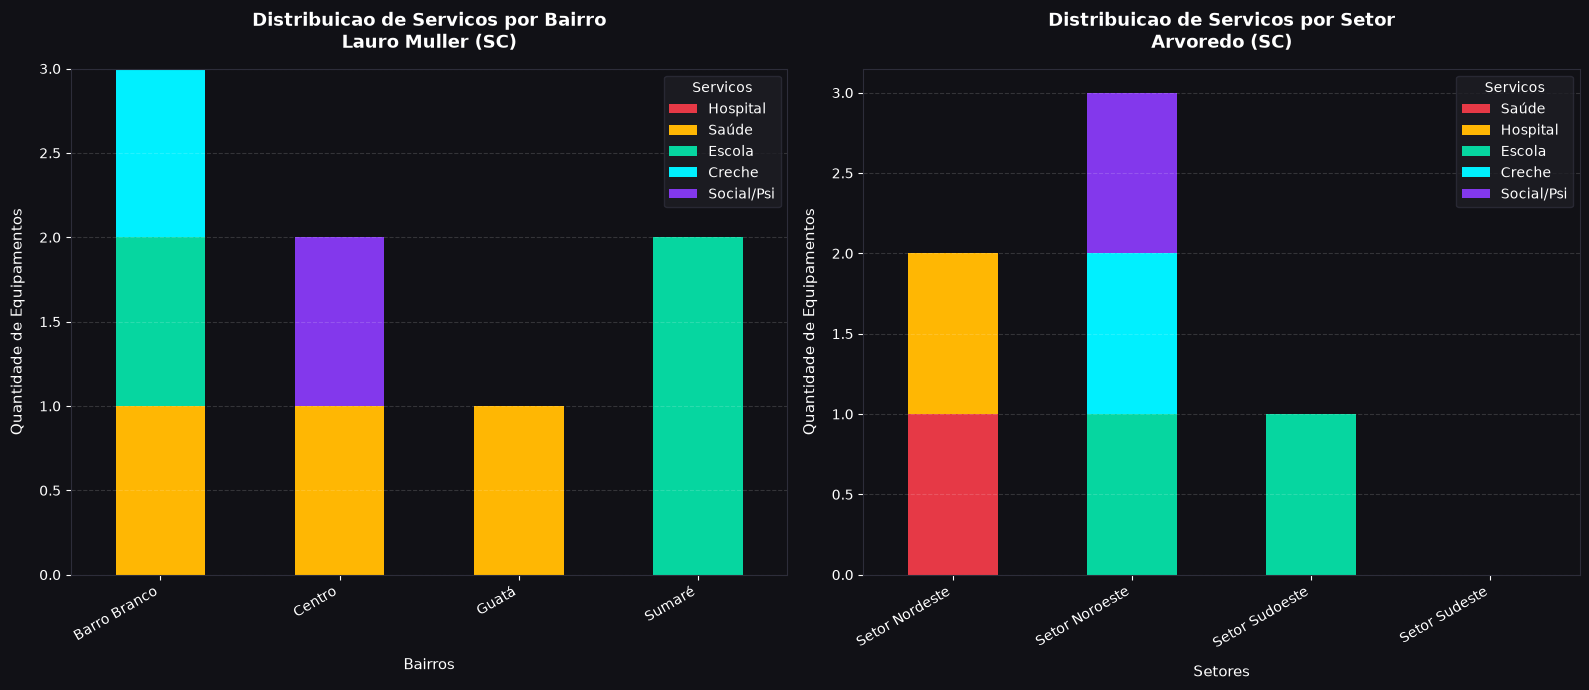

In [48]:
# Geracao de graficos comparativos de densidade usando matplotlib
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#111116')

for ax in axes:
    ax.set_facecolor('#111116')
    ax.tick_params(colors='#ffffff', labelsize=10)
    ax.xaxis.label.set_color('#ffffff')
    ax.yaxis.label.set_color('#ffffff')
    ax.title.set_color('#ffffff')
    for spine in ax.spines.values():
        spine.set_color('#2d2d3a')

cores_servicos_chart = ['#E63946', '#FFB703', '#06D6A0', '#00F0FF', '#8338EC']

# Grafico Lauro Muller
df_plot_lauro = tab_lauro.drop(columns='Total Geral')
df_plot_lauro.plot(kind='bar', stacked=True, ax=axes[0], color=cores_servicos_chart)
axes[0].set_title('Distribuicao de Servicos por Bairro\nLauro Muller (SC)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Bairros', fontsize=11, labelpad=10)
axes[0].set_ylabel('Quantidade de Equipamentos', fontsize=11, labelpad=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.15, color='#ffffff')
leg1 = axes[0].legend(title='Servicos', facecolor='#1e1e24', edgecolor='#2d2d3a', labelcolor='#ffffff')
leg1.get_title().set_color('#ffffff')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Grafico Arvoredo
df_plot_arvoredo = tab_arvoredo.drop(columns='Total Geral')
df_plot_arvoredo.plot(kind='bar', stacked=True, ax=axes[1], color=cores_servicos_chart)
axes[1].set_title('Distribuicao de Servicos por Setor\nArvoredo (SC)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Setores', fontsize=11, labelpad=10)
axes[1].set_ylabel('Quantidade de Equipamentos', fontsize=11, labelpad=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.15, color='#ffffff')
leg2 = axes[1].legend(title='Servicos', facecolor='#1e1e24', edgecolor='#2d2d3a', labelcolor='#ffffff')
leg2.get_title().set_color('#ffffff')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('grafico_densidade_servicos.png', dpi=300, facecolor='#111116', bbox_inches='tight')
plt.show()

## 4 - Relatórios e Recomendações

Com base nas análises de distâncias, raios de cobertura e densidade por bairro, apresentamos a seguir os relatórios analíticos de cada município e as recomendações para tomada de decisões e planejamento de políticas públicas de acessibilidade viária.

### Relatório: Lauro Müller (SC)

#### Distâncias
- **Centro:** todos os serviços ficam a menos de 600 m da Prefeitura.
- **Barro Branco:** escola, creche e posto de saúde ficam junto ao ponto de referência. O hospital fica a 3,2 km e o CRAS a 3,6 km.
- **Guatá:** o posto de saúde fica junto ao ponto de referência. Escola, hospital, creche e CRAS ficam a cerca de 5 km.

> Quando aparece 0 m, o serviço e a referência estão ligados ao mesmo ponto da rua no grafo.

#### Serviços por bairro

| Bairro | O que possui | O que falta |
|---|---|---|
| Centro | Saúde e CRAS | Hospital, escola e creche |
| Barro Branco | Saúde, escola e creche | Hospital e CRAS |
| Guatá | Saúde | Hospital, escola, creche e CRAS |
| Sumaré | Escolas | Hospital, saúde, creche e CRAS |

#### Resultado
- O Centro tem o melhor acesso aos serviços.
- Barro Branco atende bem saúde e educação, mas fica longe do hospital e do CRAS.
- Guatá é o bairro com maior falta de serviços. Apenas o posto de saúde está perto.

#### Sugestões
- Criar uma **creche em Guatá**, pois a atual fica a cerca de 5 km.
- Criar um **ponto de atendimento do CRAS em Guatá**, onde a distância atual é de 5,2 km.
- Oferecer atendimento do **CRAS em Barro Branco**, de forma fixa ou em alguns dias da semana.
- As regiões próximas às referências de Guatá (`-28.381083, -49.438467`) e Barro Branco (`-28.414881, -49.412235`) podem ser estudadas como locais iniciais.

### Relatório: Arvoredo (SC)

#### Distâncias
- **Prefeitura:** todos os serviços ficam a até 1 km.
- **Praça Central:** escola, creche e CRAS ficam perto. Saúde e atendimento hospitalar ficam a 1,2 km.
- **Pórtico:** saúde e atendimento hospitalar ficam a cerca de 290 m. Escola e CRAS ficam a 1,1 km, e a creche a 1,5 km.

> O raio mostra a distância em linha reta. A rota usa as ruas. Por isso, os valores podem ser diferentes.

#### Serviços por setor

| Setor | O que possui | O que falta |
|---|---|---|
| Nordeste | Saúde e atendimento hospitalar | Escola, creche e CRAS |
| Noroeste | Escola, creche e CRAS | Saúde e atendimento hospitalar |
| Sudoeste | Escola | Saúde, hospital, creche e CRAS |
| Sudeste | Nenhum serviço | Todos os serviços analisados |

#### Resultado
- A Prefeitura tem o acesso mais equilibrado.
- O Pórtico fica mais longe da creche, da escola e do CRAS.
- O Setor Sudeste não possui nenhum dos serviços analisados.
- O Setor Sudoeste possui apenas escola.

#### Sugestões
- Criar uma **creche próxima ao Pórtico ou no Setor Sudeste**, pois a atual fica a 1,5 km.
- Criar um **ponto de atendimento básico no Setor Sudeste**, que hoje não possui nenhum serviço analisado.
- Avaliar atendimento de **saúde e CRAS no Setor Sudoeste**, que possui apenas escola.
- A região próxima ao Pórtico (`-27.073800, -52.448500`) pode ser usada como ponto inicial para estudar um novo serviço.